Построим графики на основе информации из разных новостных статей. Для некоторых годов информации может не быть. Для некоторых годов информация может быть неточной или расходиться. Но лучшего способа собрать статистику кроме как из таких статей нет. Потому что никто такую статистику не собирает.

Первая статья https://qz.com/742474/how-streaming-video-changed-the-shape-of-the-internet?utm_source=chatgpt.com
- в 2008 Bittorrent 33% всего трафика
- в 2016 Bittorrent 1% всего трафика
- в 2009 Google более 5% всего трафика

Вторая статья https://www.nexttv.com/news/video-demand-now-27-internet-traffic-study-298719
- в 2008 streaming-video (включая ютуб) 13% всего трафика
- в 2009 streaming-video (включа ютуб) 27% всего трафика
- В 2008 peer-to-peer (bit torrent) 32% всего трафика
- В 2009 peer-to-peer (bit torrent) 20% всего трафика

Третья статья https://en.wikipedia.org/wiki/Internet_traffic
- в 2008 Bittorrent 31% доля трафика
- в 2013 Bittorent 7.4 процента доля трафика

Четвертая статья https://www.prnewswire.com/news-releases/sandvines-2023-global-internet-phenomena-report-shows-24-jump-in-video-traffic-with-netflix-volume-overtaking-youtube-301723445.html

В ней говорится что в 2022 доля видео-трафика состовляет 65%. При этом упоминается, что netflix обогнал youtube по объему трафика

Пятая статья https://torrentfreak.com/bittorrent-is-no-longer-the-king-of-upstream-internet-traffic-240315/?utm_source=chatgpt.com
- В 2004 BitTorrent - 35% всего трафика
- В 2013 BitTorrent - 33% всего upload трафика
- В 2022 BitTorrent - 10% всего upload трафика
- В 2024 BitTorrent - 4% всего upload трафика


Также на основе отчетов Sandvine разных годов, имеем следющие данные:

BitTorrent -- Downstream


2004-35%

2008-31%

2011-19%

2012-11%

2013-9.2%

2015 - 6%

2019 - 2.46%

2022 - 2.91%

YouTube -- Downstream


2012 - 13.8%

2013 - -17.1%

2014 ~ 14%

2015 - 17.9%

2022 - 11.4%

BitTorrent -- Upstream

2008 ~ 71%

2011 - 52%

2015 ~ 27%

2019 - 27.58%

2022 ~ 10%

2024 - 4%

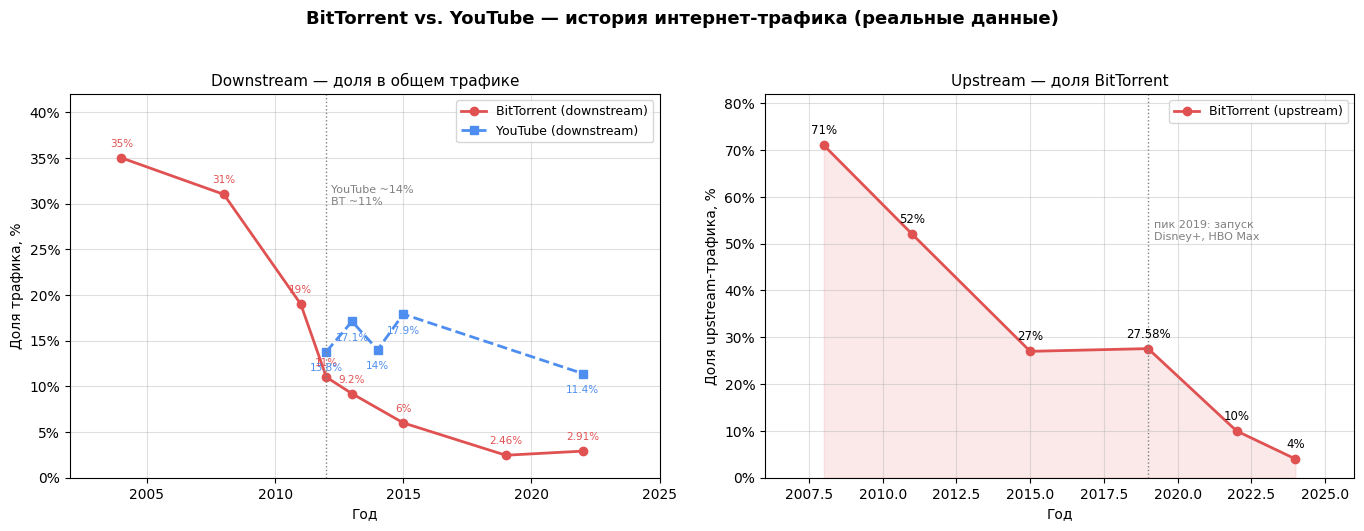

Сохранено: traffic_charts.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bt_years_d  = [2004, 2008, 2011, 2012, 2013, 2015, 2019, 2022]
bt_down     = [35,   31,   19,   11,   9.2,  6,    2.46, 2.91]


yt_years    = [2012, 2013, 2014, 2015, 2022]
yt_down     = [13.8, 17.1, 14,   17.9, 11.4]

years_up  = [2008, 2011, 2015, 2019, 2022, 2024]
bt_up     = [71,   52,   27,   27.58, 10,   4   ]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("BitTorrent vs. YouTube — история интернет-трафика (реальные данные)", fontsize=13, fontweight='bold')

# График 1: Downstream
ax1.set_title("Downstream — доля в общем трафике", fontsize=11)

ax1.plot(bt_years_d, bt_down, "o-", color="#e05252", label="BitTorrent (downstream)", linewidth=2)
ax1.plot(yt_years,   yt_down, "s--", color="#4e8ef0", label="YouTube (downstream)", linewidth=2)

ax1.axvline(2012, color="gray", linewidth=1, linestyle=":")
ax1.text(2012.2, 32, "YouTube ~14%\nBT ~11%", color="gray", fontsize=8, va="top")

ax1.set_xlabel("Год")
ax1.set_ylabel("Доля трафика, %")
ax1.set_xlim(2002, 2025)
ax1.set_ylim(0, 42)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax1.grid(True, alpha=0.4)
ax1.legend(fontsize=9)


for x, y in zip(bt_years_d, bt_down):
    ax1.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=7.5, color="#e05252")
for x, y in zip(yt_years, yt_down):
    ax1.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, -14),
                 ha='center', fontsize=7.5, color="#4e8ef0")

# График 2: Upstream BitTorrent
ax2.set_title("Upstream — доля BitTorrent", fontsize=11)
ax2.plot(years_up, bt_up, "o-", color="#e05252", label="BitTorrent (upstream)", linewidth=2)
ax2.fill_between(years_up, bt_up, alpha=0.12, color="#e05252")

ax2.axvline(2019, color="gray", linewidth=1, linestyle=":")
ax2.text(2019.2, 55, "пик 2019: запуск\nDisney+, HBO Max", color="gray", fontsize=8, va="top")

for x, y in zip(years_up, bt_up):
    ax2.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=8.5)

ax2.set_xlabel("Год")
ax2.set_ylabel("Доля upstream-трафика, %")
ax2.set_xlim(2006, 2026)
ax2.set_ylim(0, 82)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.grid(True, alpha=0.4)
ax2.legend(fontsize=9)



plt.tight_layout(pad=2.0)
plt.savefig("traffic_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: traffic_charts.png")

Начиная с 2012 года значительная часть трафика bittorrent шифруется с помощью vpn, соответственно, реальные значения могут быть немного больше.

Еще можно посмотреть популярность поисковых запросов связанных с Bittorrent и с Youtube. Понять из этого объем трафика конечно нельзя, но можно предположить когда примерно та или иная технология становилась популярнее, чем другая


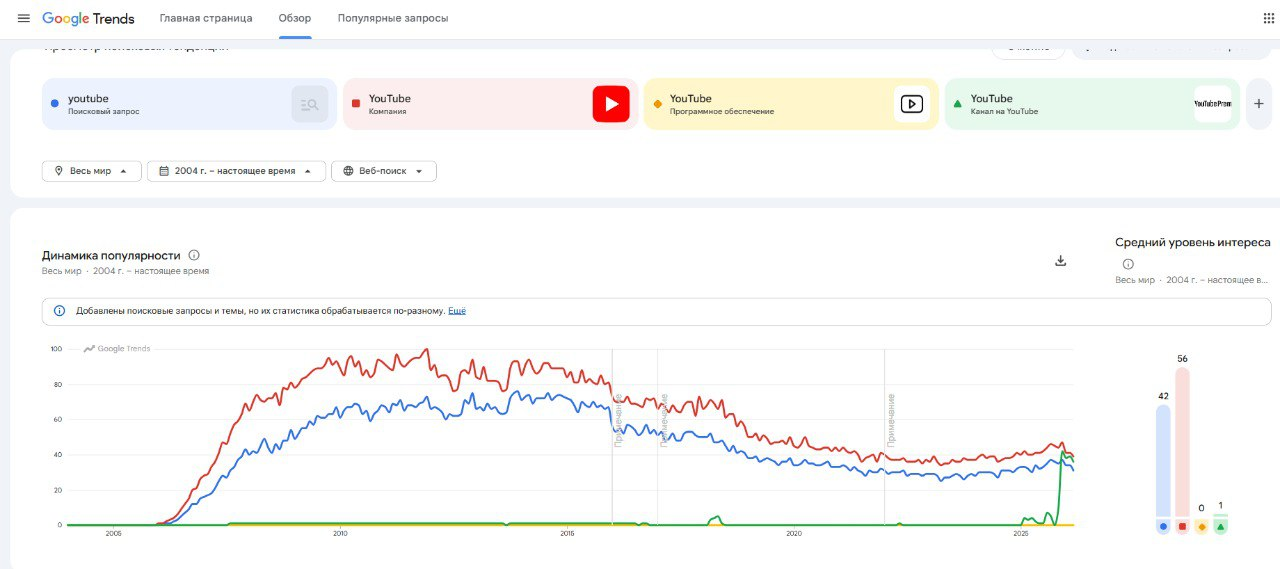

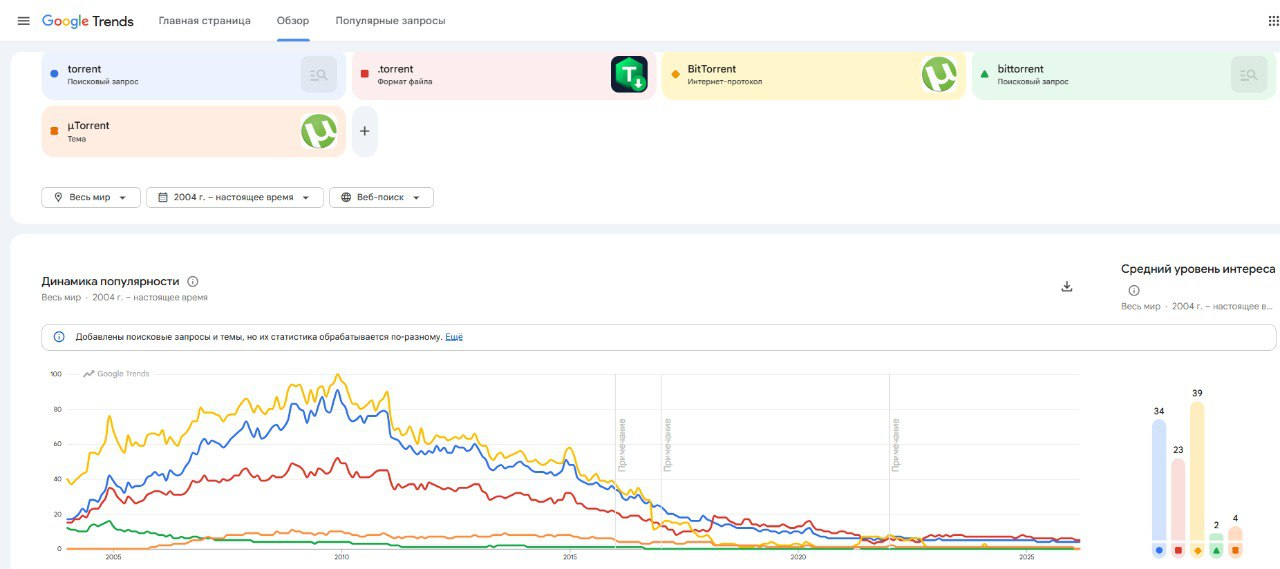

Как можно заметить из этих графиков, до появления youtube bittorent был довольно популярной технологией. После появления youtube в 2005-2007 и до 2010 популярность этих двух технологий росла вместе, а вот после 2010 года Bittorrent стал уходить в прошлое
